In [1]:
import cv2
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import numpy as np
import imutils
from skimage.feature import blob_dog, blob_log


In [2]:
pwd

'/home/yuxin.chang/fantastx/examples/from_Thiago/yuxin_edit/ssim_tests'

(116, 155)


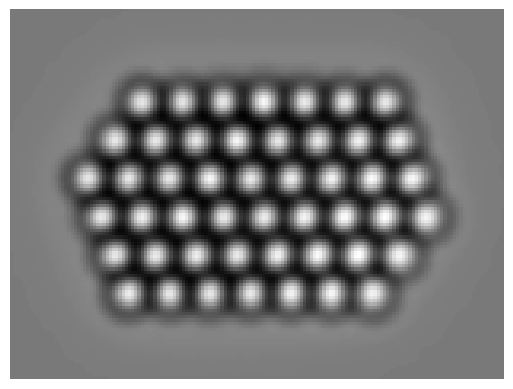

In [13]:
original_img = cv2.imread('cropped_image.png', cv2.IMREAD_GRAYSCALE)
print(original_img.shape)
plt.imshow(original_img,cmap='gray')
plt.axis('off')
plt.show()

In [14]:
# Specify the scaling factor for zooming
zoom_factor = 1.05

zoomed_img = original_img[round(0.5*original_img.shape[0]*(zoom_factor-1)/zoom_factor):round(0.5*original_img.shape[0]*(zoom_factor+1)/zoom_factor),round(0.5*original_img.shape[1]*(zoom_factor-1)/zoom_factor):round(0.5*original_img.shape[1]*(zoom_factor+1)/zoom_factor)]
zoomed_img = cv2.resize(zoomed_img,(original_img.shape[1],original_img.shape[0]))
print(zoomed_img.shape)

(116, 155)


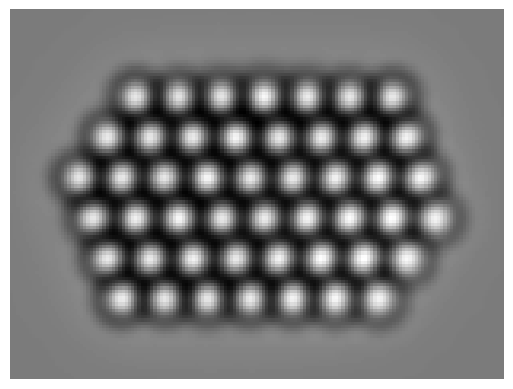

In [15]:
plt.imshow(zoomed_img,cmap='gray')
plt.axis('off')
plt.show()

In [16]:
(score, diff) = ssim(zoomed_img, original_img, full=True)
diff = (diff * 255).astype("uint8")
print(score)

0.7672973840520041


In [17]:
# threshold the difference image, followed by finding contours to
# obtain the regions of the two input images that differ
thresh = cv2.threshold(diff, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

Text(0.5, 1.0, 'thresh')

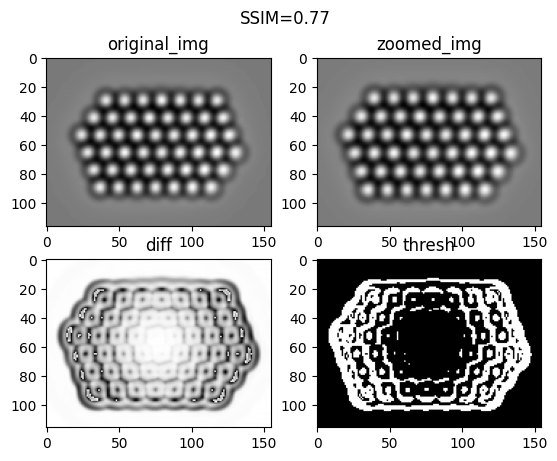

In [18]:
plt.suptitle(f'SSIM={round(score,2)}')
plt.subplot(2, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(2, 2, 2)
plt.imshow(zoomed_img, cmap='gray')
plt.title('zoomed_img')

plt.subplot(2, 2, 3)
plt.imshow(diff, cmap='gray')
plt.title('diff')

plt.subplot(2, 2, 4)
plt.imshow(thresh, cmap='gray')
plt.title('thresh')

Text(0.5, 1.0, 'diff')

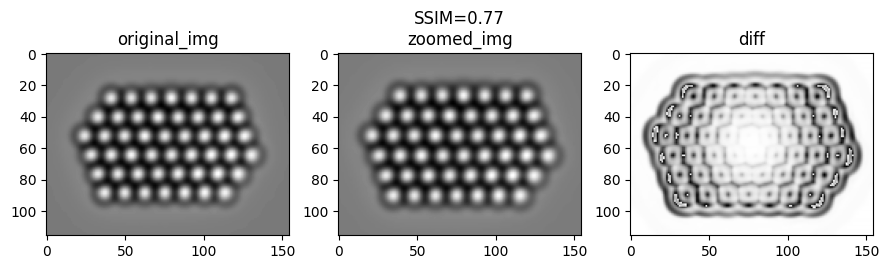

In [41]:
plt.figure(figsize=(9, 3))
plt.title(f'SSIM={round(score,2)}')
plt.tight_layout()

plt.axis('off')
plt.subplot(1, 3, 1)
# plt.axis('off')
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(1, 3, 2)
# plt.axis('off')
plt.imshow(zoomed_img, cmap='gray')
plt.title('zoomed_img')

plt.subplot(1, 3, 3)
# plt.axis('off')
plt.imshow(diff, cmap='gray')
plt.title('diff')



0.9569786229226098


Text(0.5, 1.0, 'thresh')

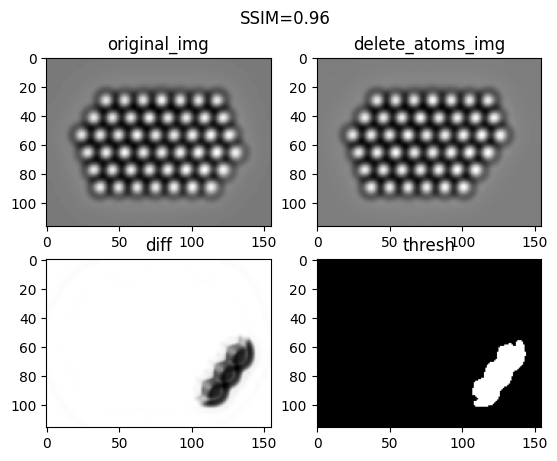

In [42]:
original_img_2 = cv2.imread('cropped_image_2.png', cv2.IMREAD_GRAYSCALE)
(score, diff) = ssim(original_img_2, original_img, full=True)
diff = (diff * 255).astype("uint8")
print(score)
thresh = cv2.threshold(diff, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

plt.suptitle(f'SSIM={round(score,2)}')
plt.subplot(2, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(2, 2, 2)
plt.imshow(original_img_2, cmap='gray')
plt.title('delete_atoms_img')

plt.subplot(2, 2, 3)
plt.imshow(diff, cmap='gray')
plt.title('diff')

plt.subplot(2, 2, 4)
plt.imshow(thresh, cmap='gray')
plt.title('thresh')

Text(0.5, 1.0, 'diff')

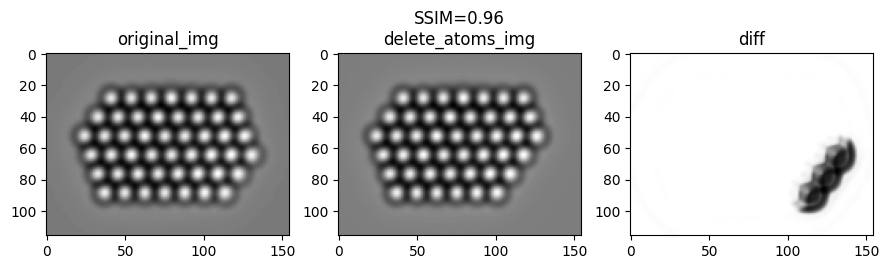

In [43]:
plt.figure(figsize=(9, 3))
plt.title(f'SSIM={round(score,2)}')
plt.tight_layout()

plt.axis('off')
plt.subplot(1, 3, 1)
# plt.axis('off')
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(1, 3, 2)
# plt.axis('off')
plt.imshow(original_img_2, cmap='gray')
plt.title('delete_atoms_img')

plt.subplot(1, 3, 3)
# plt.axis('off')
plt.imshow(diff, cmap='gray')
plt.title('diff')


(116, 7)
0.33193464129933237


Text(0.5, 1.0, 'thresh')

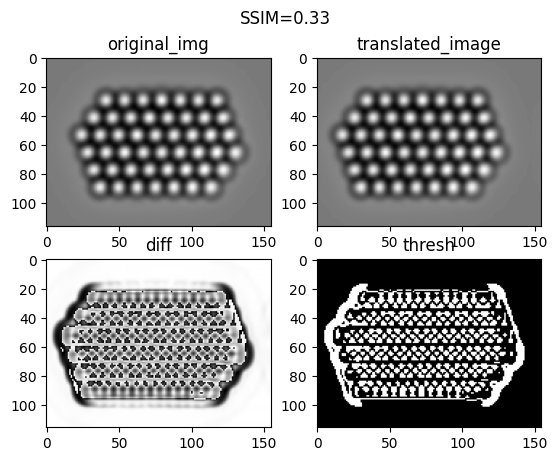

In [44]:
# Get the width of the image
width = original_img.shape[1]

# Extract the first 5 pixels along the x-axis
first_5_pixels = original_img[:, :7]
print(first_5_pixels.shape)

# Remove the first 5 pixels from the original image
translated_image = original_img[:, 7:]

# Concatenate the first 5 pixels to the end of the image along the x-axis
translated_image = np.concatenate((translated_image, first_5_pixels), axis=1)


(score, diff) = ssim(translated_image, original_img, full=True)
diff = (diff * 255).astype("uint8")
print(score)

thresh = cv2.threshold(diff, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

plt.suptitle(f'SSIM={round(score,2)}')
plt.subplot(2, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(2, 2, 2)
plt.imshow(translated_image, cmap='gray')
plt.title('translated_image')

plt.subplot(2, 2, 3)
plt.imshow(diff, cmap='gray')
plt.title('diff')

plt.subplot(2, 2, 4)
plt.imshow(thresh, cmap='gray')
plt.title('thresh')

Text(0.5, 1.0, 'diff')

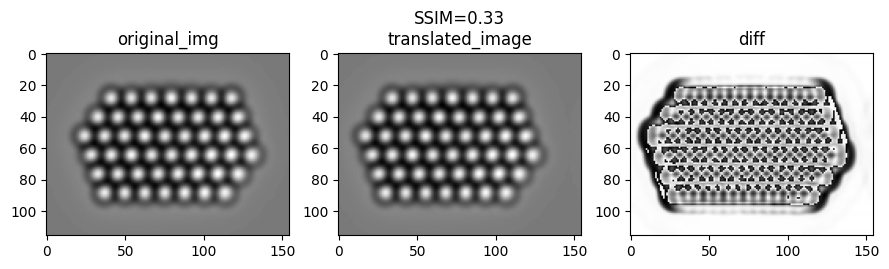

In [45]:
plt.figure(figsize=(9, 3))
plt.title(f'SSIM={round(score,2)}')
plt.tight_layout()

plt.axis('off')
plt.subplot(1, 3, 1)
# plt.axis('off')
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(1, 3, 2)
# plt.axis('off')
plt.imshow(translated_image, cmap='gray')
plt.title('translated_image')

plt.subplot(1, 3, 3)
# plt.axis('off')
plt.imshow(diff, cmap='gray')
plt.title('diff')


0.6509332680472159


Text(0.5, 1.0, 'thresh')

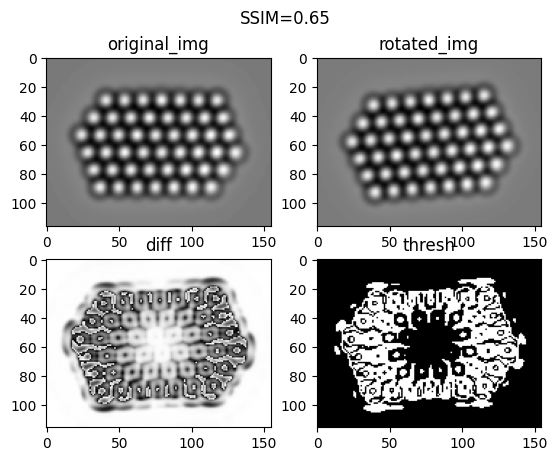

In [48]:
def rotate_img(img,angle):
    height, width = img.shape[:2]
    # Calculate the rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D((width/2, height/2), angle, 1)
    # Perform the rotation
    rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height),borderValue=int(img[0][0]))
    return rotated_img

rotated_img = rotate_img(original_img,angle=5)


(score, diff) = ssim(rotated_img, original_img, full=True)
diff = (diff * 255).astype("uint8")
print(score)

thresh = cv2.threshold(diff, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

plt.suptitle(f'SSIM={round(score,2)}')
plt.subplot(2, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(2, 2, 2)
plt.imshow(rotated_img, cmap='gray')
plt.title('rotated_img')

plt.subplot(2, 2, 3)
plt.imshow(diff, cmap='gray')
plt.title('diff')

plt.subplot(2, 2, 4)
plt.imshow(thresh, cmap='gray')
plt.title('thresh')

Text(0.5, 1.0, 'diff')

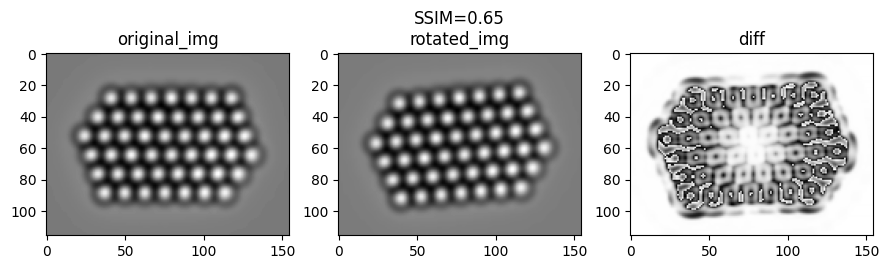

In [49]:
plt.figure(figsize=(9, 3))
plt.title(f'SSIM={round(score,2)}')
plt.tight_layout()

plt.axis('off')
plt.subplot(1, 3, 1)
# plt.axis('off')
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(1, 3, 2)
# plt.axis('off')
plt.imshow(rotated_img, cmap='gray')
plt.title('rotated_img')

plt.subplot(1, 3, 3)
# plt.axis('off')
plt.imshow(diff, cmap='gray')
plt.title('diff')


0.22287371859645128


Text(0.5, 1.0, 'thresh')

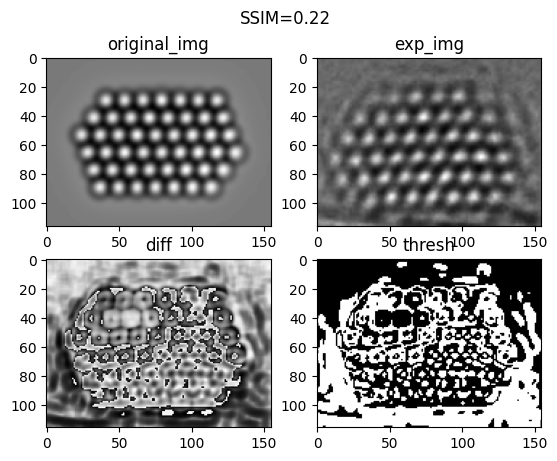

In [11]:
exp_img = cv2.imread('Exp_img.jpg', cv2.IMREAD_GRAYSCALE)
(score, diff) = ssim(exp_img, original_img, full=True)
diff = (diff * 255).astype("uint8")
print(score)

thresh = cv2.threshold(diff, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

plt.suptitle(f'SSIM={round(score,2)}')
plt.subplot(2, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title('original_img')

plt.subplot(2, 2, 2)
plt.imshow(exp_img, cmap='gray')
plt.title('exp_img')

plt.subplot(2, 2, 3)
plt.imshow(diff, cmap='gray')
plt.title('diff')

plt.subplot(2, 2, 4)
plt.imshow(thresh, cmap='gray')
plt.title('thresh')

do some test on blob definition, see how good it can tract boundary in exp img

In [82]:
experimental_blobs = blob_dog(exp_img, max_sigma=5, threshold=0.03)
experimental_central_point = np.mean(experimental_blobs, axis=0)[:2].astype(int)

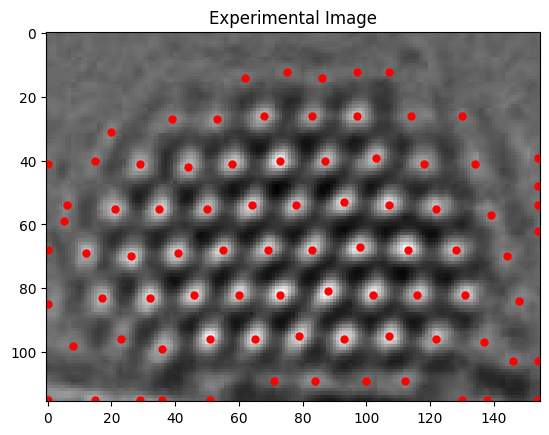

In [85]:
plt.imshow(exp_img, cmap='gray')
plt.title('Experimental Image')
for blob in experimental_blobs:
    y, x, _ = blob
    plt.plot(x, y,'ro', markersize=5)  # Red points for experimental atoms